In [2]:
# --- Import all libraries once ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestClassifier


In [3]:
# Example dataset (replace with your actual data)
df = pd.DataFrame({
    'Open': [100, 102, 101, 103, 104, 106, 107],
    'Close': [102, 101, 103, 105, 106, 108, 110],
    'High': [103, 103, 104, 106, 107, 109, 111],
    'Low': [99, 100, 100, 102, 103, 105, 106],
    'Volume': [200, 220, 210, 250, 260, 280, 300],
    'SMA': [101, 101.5, 102, 104, 105, 106, 108],
    'RSI': [45, 50, 48, 55, 60, 62, 58],
    'Price_Movement': [1, 0, 1, 1, 1, 0, 1]
})


In [4]:
# Prepare data
features = ['Open', 'Close', 'High', 'Low', 'Volume', 'SMA', 'RSI']
target = 'Price_Movement'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X_test)
rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))

# SVR
svr = SVR(kernel='rbf')
svr.fit(X_train, y_train)
y_pred_svr = svr.predict(X_test)
rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))

# Bayesian Ridge
bayesian = BayesianRidge()
bayesian.fit(X_train, y_train)
y_pred_bayesian = bayesian.predict(X_test)
rmse_bayesian = np.sqrt(mean_squared_error(y_test, y_pred_bayesian))


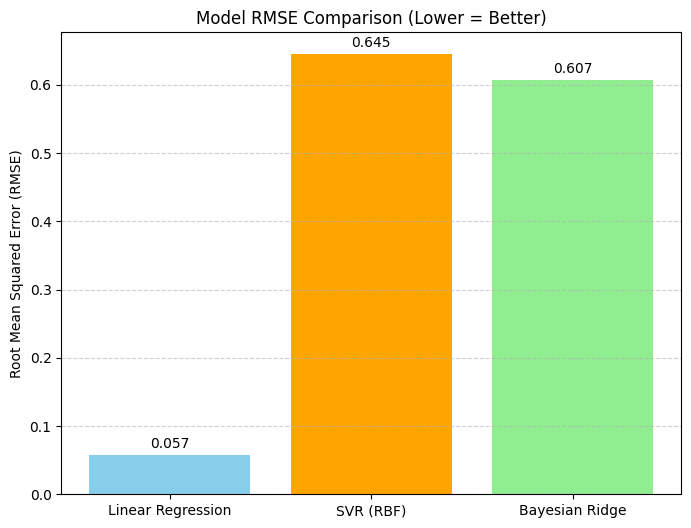

In [5]:
model_names = ['Linear Regression', 'SVR (RBF)', 'Bayesian Ridge']
rmse_values = [rmse_lin, rmse_svr, rmse_bayesian]

plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, rmse_values, color=['skyblue', 'orange', 'lightgreen'])
plt.bar_label(bars, fmt='%.3f', padding=3)
plt.title("Model RMSE Comparison (Lower = Better)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()


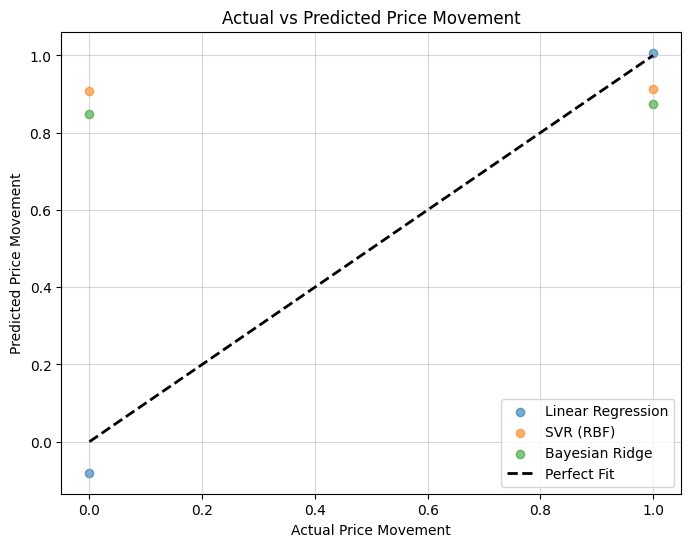

In [6]:
# --- Actual vs Predicted Scatter Plot ---
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_lin, alpha=0.6, label='Linear Regression')
plt.scatter(y_test, y_pred_svr, alpha=0.6, label='SVR (RBF)')
plt.scatter(y_test, y_pred_bayesian, alpha=0.6, label='Bayesian Ridge')

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Fit')
plt.title("Actual vs Predicted Price Movement")
plt.xlabel("Actual Price Movement")
plt.ylabel("Predicted Price Movement")
plt.legend()
plt.grid(alpha=0.5)
plt.show()


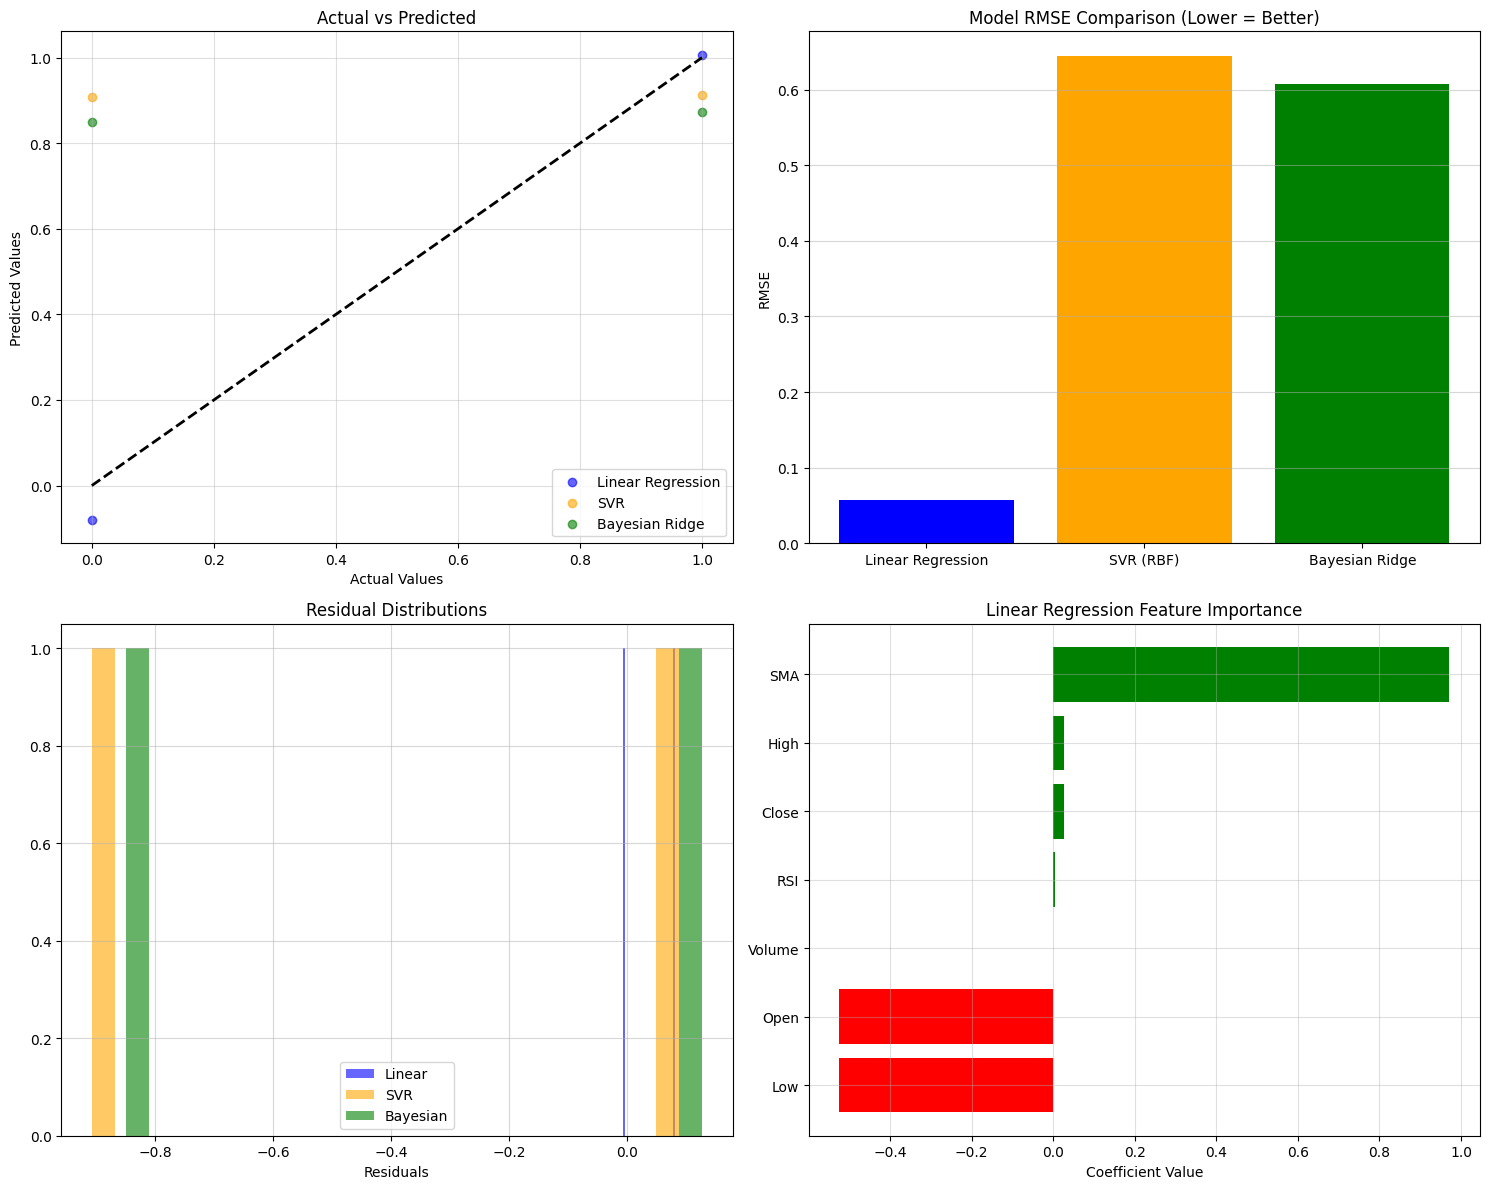

In [7]:
# --- Combined Summary Dashboard ---

# 1️⃣ Calculate residuals for all models
residuals_lin = y_test - y_pred_lin
residuals_svr = y_test - y_pred_svr
residuals_bayesian = y_test - y_pred_bayesian

# 2️⃣ Create figure layout
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# --- Scatter Plot (Actual vs Predicted) ---
axs[0, 0].scatter(y_test, y_pred_lin, alpha=0.6, label='Linear Regression', color='blue')
axs[0, 0].scatter(y_test, y_pred_svr, alpha=0.6, label='SVR', color='orange')
axs[0, 0].scatter(y_test, y_pred_bayesian, alpha=0.6, label='Bayesian Ridge', color='green')
axs[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axs[0, 0].set_title("Actual vs Predicted")
axs[0, 0].set_xlabel("Actual Values")
axs[0, 0].set_ylabel("Predicted Values")
axs[0, 0].legend()
axs[0, 0].grid(alpha=0.4)

# --- RMSE Comparison ---
axs[0, 1].bar(model_names, rmse_values, color=['blue', 'orange', 'green'])
axs[0, 1].set_title("Model RMSE Comparison (Lower = Better)")
axs[0, 1].set_ylabel("RMSE")
axs[0, 1].grid(axis='y', alpha=0.5)

# --- Residual Histograms ---
axs[1, 0].hist(residuals_lin, bins=25, alpha=0.6, label='Linear', color='blue')
axs[1, 0].hist(residuals_svr, bins=25, alpha=0.6, label='SVR', color='orange')
axs[1, 0].hist(residuals_bayesian, bins=25, alpha=0.6, label='Bayesian', color='green')
axs[1, 0].set_title("Residual Distributions")
axs[1, 0].set_xlabel("Residuals")
axs[1, 0].legend()
axs[1, 0].grid(alpha=0.5)

# --- Feature Importance (using Linear Regression coefficients) ---
importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lin_reg.coef_
}).sort_values(by='Coefficient', ascending=True)

colors = ['green' if c > 0 else 'red' for c in importance_df['Coefficient']]
axs[1, 1].barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)
axs[1, 1].set_title("Linear Regression Feature Importance")
axs[1, 1].set_xlabel("Coefficient Value")
axs[1, 1].grid(alpha=0.4)

# --- Adjust layout ---
plt.tight_layout()
plt.show()


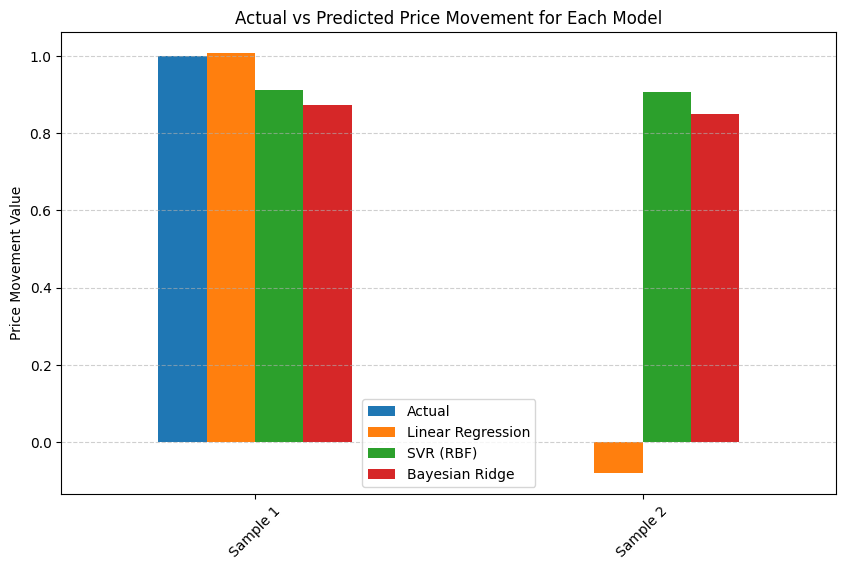

In [8]:
# --- 📈 Additional Visualization 2: Actual vs Predicted Comparison ---
comparison_df = pd.DataFrame({
    'Actual': y_test.values,
    'Linear Regression': y_pred_lin,
    'SVR (RBF)': y_pred_svr,
    'Bayesian Ridge': y_pred_bayesian
})

comparison_df.index = [f'Sample {i+1}' for i in range(len(comparison_df))]

comparison_df.plot(kind='bar', figsize=(10,6))
plt.title("Actual vs Predicted Price Movement for Each Model")
plt.ylabel("Price Movement Value")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.legend()
plt.show()
